In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/bothsimages/underwater_uiebd-20260329T073828Z-3-001.zip /content/

In [ ]:
!unzip -q /content/underwater_uiebd-20260329T073828Z-3-001.zip -d /content/

In [ ]:

!pip install scikit-learn

In [ ]:
!pip install pytorch_wavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.2 MB/s eta 0:00:00


In [ ]:
import os
import time
import glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torchvision.models as models
import matplotlib.pyplot as plt

!pip install PyWavelets


from pytorch_wavelets import DWTForward

# Train Test Split

In [ ]:
import os
import glob
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image


master_input_dir = "/content/underwater_uiebd/trainA"
master_gt_dir = "/content/underwater_uiebd/trainB"


raw_input_paths = glob.glob(os.path.join(master_input_dir, "*.*"))
raw_gt_paths = glob.glob(os.path.join(master_gt_dir, "*.*"))


input_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in raw_input_paths}
gt_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in raw_gt_paths}


common_stems = sorted(list(set(input_dict.keys()).intersection(set(gt_dict.keys()))))


all_input_paths = [input_dict[stem] for stem in common_stems]
all_gt_paths = [gt_dict[stem] for stem in common_stems]

print(f"Original Inputs: {len(raw_input_paths)}")
print(f"Original GTs: {len(raw_gt_paths)}")
print(f"Successfully paired images: {len(all_input_paths)}")

assert len(all_input_paths) == len(all_gt_paths), "Mismatch in number of input and GT images!"

#   Spliting of dataset (90% Train 10% Test)
train_inputs, test_inputs, train_gts, test_gts = train_test_split(
    all_input_paths, all_gt_paths, test_size=0.10, random_state=42
)

print(f"Training: {len(train_inputs)} | Testing: {len(test_inputs)}")

#  Updated Dataset Class
class UnderwaterDataset(Dataset):
    def __init__(self, input_paths, gt_paths):
        self.input_paths = input_paths
        self.gt_paths = gt_paths

        # Resize to 256x256 and normalize to [-1, 1]
        self.transform = transforms.Compose([
            transforms.Resize((256, 256), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.input_paths)

    def __getitem__(self, idx):
        inp_img = Image.open(self.input_paths[idx]).convert('RGB')
        gt_img = Image.open(self.gt_paths[idx]).convert('RGB')
        return self.transform(inp_img), self.transform(gt_img)

#  Create the DataLoaders
train_dataset = UnderwaterDataset(train_inputs, train_gts)
train_loader = DataLoader(
    train_dataset,
    batch_size=6,
    shuffle=True,

    num_workers=2,
    pin_memory=True
)


test_dataset = UnderwaterDataset(test_inputs, test_gts)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Original Inputs: 10757
Original GTs: 10688
Successfully paired images: 10680
Training: 9612 | Testing: 1068


# Vizualization of Input and Ground Truth images

Text(0.5, 1.0, 'Input image')

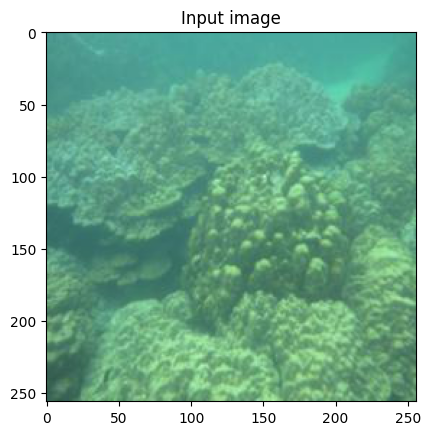

In [ ]:
sample_image = train_loader.dataset[0][0]

dennormalized_image = sample_image * 0.5 + 0.5


image_to_plot = dennormalized_image.permute(1, 2, 0)

plt.imshow(image_to_plot.numpy())
plt.title("Input image")

Text(0.5, 1.0, 'Ground Truth')

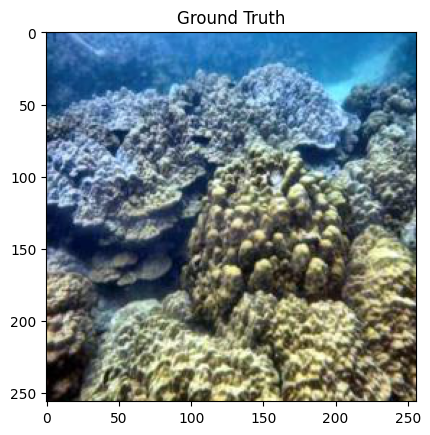

In [ ]:
sample_image = train_loader.dataset[0][1]

dennormalized_image = sample_image * 0.5 + 0.5


image_to_plot = dennormalized_image.permute(1, 2, 0)

plt.imshow(image_to_plot.numpy())
plt.title("Ground Truth")

#  **Model Definition**

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class S_D(nn.Module):
    def __init__(self):
        super(S_D, self).__init__()
        self.A = nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1, dilation=1)
        self.B = nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=5, dilation=5)
        self.LReLU = nn.LeakyReLU(0.2, inplace=True)
        self.Sigmoid = nn.Sigmoid()

    def forward(self, x):
        A1 = self.LReLU(self.A(x))
        A2 = self.LReLU(self.B(x))
        A3 = A1 - A2
        Guided_map = self.Sigmoid(A3)
        Detail_map = x * Guided_map
        Structure_map = x - Detail_map

        return Structure_map, Detail_map


class simam_module(nn.Module):
    def __init__(self, e_lambda=1e-4):
        super(simam_module, self).__init__()
        self.activaton = nn.Sigmoid()
        self.e_lambda = e_lambda

    def __repr__(self):
        s = self.__class__.__name__ + '('
        s += ('lambda=%f)' % self.e_lambda)

        return s

    def forward(self, x):
        b, c, h, w = x.size()
        n = w * h - 1
        x_minus_mu_square = (x - x.mean(dim=[2, 3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (4 * (x_minus_mu_square.sum(dim=[2, 3], keepdim=True) / n + self.e_lambda)) + 0.5

        return self.activaton(y)


class SD_3D(nn.Module):
    def __init__(self):
        super(SD_3D, self).__init__()
        self.SD = S_D()
        self.sim = simam_module()

    def forward(self, x):
        Structure_map, Detail_map = self.SD(x)
        M1_0 = self.sim(Structure_map)
        M2_0 = M1_0 * Detail_map
        M1_1 = self.sim(M2_0)
        M2_1 = M1_1 * Detail_map
        M1_2 = self.sim(M2_1)
        M2_2 = M1_2 * Detail_map

        return M2_2, M2_1, M2_0




In [ ]:
class BOths(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(BOths, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1, bias=True)

        self.LReLU = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.In1 = nn.InstanceNorm2d(16)
        self.SD3D = SD_3D()

        self.gate = nn.Conv2d(16 * 3, 3, 3, 1, 1, bias=True)
        self.Final = nn.Conv2d(19, out_channels, kernel_size=1, stride=1, padding=0, bias=True)

    def forward(self, x):
        en = self.conv1(x)
        en = self.LReLU(en)
        en = self.In1(en)
        # SD3D
        sd2, sd1, sd0 = self.SD3D(en)
        # Gate
        gates = self.gate(torch.cat((sd0, sd1, sd2), dim=1))
        gated_X = sd0 * gates[:, [0], :, :] + sd1 * gates[:, [1], :, :] + sd2 * gates[:, [2], :, :]  # 16, 256, 256
        gated_X = torch.cat((gated_X, x), dim=1)  # 19, 256, 256
        # Final
        result = self.Final(gated_X)

        return torch.tanh(result)
        # 256*256*3


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BOths().to(device)

In [ ]:
device


device(type='cuda')

# **Loss Function**

In [ ]:
class WMSELoss(nn.Module):
    def __init__(self):
        super(WMSELoss, self).__init__()
        self.dwt = DWTForward(J=1, wave='haar').to(device)
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        loss = 0
        factor = 0.25 # Factor f is set to 0.25

        # Paper states n=2 iterations
        pred_ll = pred
        target_ll = target

        for _ in range(2):
            pred_yl, pred_yh = self.dwt(pred_ll)
            target_yl, target_yh = self.dwt(target_ll)

            pred_ll = pred_yl
            target_ll = target_yl

            # High frequency parts: LH, HL, HH
            for i in range(3):
                loss += self.mse(pred_yh[0][:, :, i, :, :], target_yh[0][:, :, i, :, :]) * factor

            factor *= factor # a = a * a

        # Add Low frequency LL part
        loss += self.mse(pred_ll, target_ll) * factor
        return loss

class VGGLoss(nn.Module):
    def __init__(self):
        super(VGGLoss, self).__init__()
        # Load VGG19 and put it on the GPU
        vgg = models.vgg19(pretrained=True).features[:36].eval().to(device)

        # Freeze all VGG weights
        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        # The target image doesn't need gradients calculated, so we block them to save time/memory
        with torch.no_grad():
            target_features = self.vgg(target)


        pred_features = self.vgg(pred)

        return self.mse(pred_features, target_features)

criterion_wmse = WMSELoss()
criterion_vgg = VGGLoss()
criterion_l1 = nn.L1Loss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 139MB/s]


# **Training**

In [ ]:
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.0001)

def adjust_learning_rate(optimizer, epoch):
    # Adjusts LR according to paper specifications
    lr = 0.0001 if epoch < 30 else 0.0000001
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

In [ ]:
epoch=0

In [ ]:

start_epoch = epoch
epochs = 100

print(f"Resuming training from Epoch {start_epoch}...")

for current_epoch in range(start_epoch, epochs):

    model.train()
    adjust_learning_rate(optimizer, current_epoch)
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Loss calculation
        if current_epoch < 30:
            loss = criterion_wmse(outputs, targets)
        else:
            loss_l1 = criterion_l1(outputs, targets)
            loss_vgg = criterion_vgg(outputs, targets)
            loss = loss_l1 + 0.1 * loss_vgg

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{current_epoch+1}/{epochs}] Training Loss: {avg_loss:.4f}")


    if (current_epoch + 1) % 5 == 0:
        checkpoint_path = f"/content/drive/MyDrive/boths_checkpoints/Boths_epoch_{current_epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved to Drive: {checkpoint_path}")

# Saving the final model
torch.save(model.state_dict(), "/content/drive/MyDrive/boths_checkpoints/Boths_final_weights.pth")

Resuming training from Epoch 0...
Epoch [1/100] Training Loss: 0.0057
Epoch [2/100] Training Loss: 0.0055
Epoch [3/100] Training Loss: 0.0054
Epoch [4/100] Training Loss: 0.0054
Epoch [5/100] Training Loss: 0.0053
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_5.pth
Epoch [6/100] Training Loss: 0.0053
Epoch [7/100] Training Loss: 0.0053
Epoch [8/100] Training Loss: 0.0053
Epoch [9/100] Training Loss: 0.0053
Epoch [10/100] Training Loss: 0.0053
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_10.pth
Epoch [11/100] Training Loss: 0.0052
Epoch [12/100] Training Loss: 0.0052
Epoch [13/100] Training Loss: 0.0052
Epoch [14/100] Training Loss: 0.0052
Epoch [15/100] Training Loss: 0.0052
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_15.pth
Epoch [16/100] Training Loss: 0.0052
Epoch [17/100] Training Loss: 0.0052
Epoch [18/100] Training Loss: 0.0052
Epoch [19/100] Training Loss: 0.0052
Epoch 

In [ ]:
epoch=65

In [ ]:

checkpoint_path = "/content/drive/MyDrive/boths_checkpoints/Boths_epoch_65.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("Successfully loaded Epoch 65 checkpoint. Ready to resume!")

Successfully loaded Epoch 65 checkpoint. Ready to resume!


In [ ]:

start_epoch = epoch
epochs = 100

print(f"Resuming training from Epoch {start_epoch}...")

for current_epoch in range(start_epoch, epochs):
   #training
    model.train()
    adjust_learning_rate(optimizer, current_epoch)
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Loss calculation
        if current_epoch < 30:
            loss = criterion_wmse(outputs, targets)
        else:
            loss_l1 = criterion_l1(outputs, targets)
            loss_vgg = criterion_vgg(outputs, targets)
            loss = loss_l1 + 0.1 * loss_vgg

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{current_epoch+1}/{epochs}] Training Loss: {avg_loss:.4f}")


    if (current_epoch + 1) % 2 == 0:
        checkpoint_path = f"/content/drive/MyDrive/boths_checkpoints/Boths_epoch_{current_epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f" Checkpoint saved to Drive: {checkpoint_path}")

# Saving the final model
torch.save(model.state_dict(), "/content/drive/MyDrive/boths_checkpoints/Boths_final_weights.pth")

Resuming training from Epoch 65...
Epoch [66/100] Training Loss: 0.1419
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_66.pth
Epoch [67/100] Training Loss: 0.1419
Epoch [68/100] Training Loss: 0.1419
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_68.pth
Epoch [69/100] Training Loss: 0.1419
Epoch [70/100] Training Loss: 0.1419
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_70.pth
Epoch [71/100] Training Loss: 0.1419
Epoch [72/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_72.pth
Epoch [73/100] Training Loss: 0.1418
Epoch [74/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_74.pth
Epoch [75/100] Training Loss: 0.1418


In [ ]:
epoch=74

In [ ]:


checkpoint_path = "/content/drive/MyDrive/boths_checkpoints/Boths_epoch_74.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("Successfully loaded Epoch 74 checkpoint. Ready to resume!")

Successfully loaded Epoch 74 checkpoint. Ready to resume!


In [ ]:

start_epoch = epoch
epochs = 100

print(f"Resuming training from Epoch {start_epoch}...")

for current_epoch in range(start_epoch, epochs):

    model.train()
    adjust_learning_rate(optimizer, current_epoch)
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Loss calculation
        if current_epoch < 30:
            loss = criterion_wmse(outputs, targets)
        else:
            loss_l1 = criterion_l1(outputs, targets)
            loss_vgg = criterion_vgg(outputs, targets)
            loss = loss_l1 + 0.1 * loss_vgg

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{current_epoch+1}/{epochs}] Training Loss: {avg_loss:.4f}")


    if (current_epoch + 1) % 2 == 0:
        checkpoint_path = f"/content/drive/MyDrive/boths_checkpoints/Boths_epoch_{current_epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f" Checkpoint saved to Drive: {checkpoint_path}")

# Saving the final model
torch.save(model.state_dict(), "/content/drive/MyDrive/boths_checkpoints/Boths_final_weights.pth")

Resuming training from Epoch 74...
Epoch [75/100] Training Loss: 0.1418
Epoch [76/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_76.pth
Epoch [77/100] Training Loss: 0.1418
Epoch [78/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_78.pth
Epoch [79/100] Training Loss: 0.1418
Epoch [80/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_80.pth
Epoch [81/100] Training Loss: 0.1418


In [ ]:
epoch=80

In [ ]:


checkpoint_path = "/content/drive/MyDrive/boths_checkpoints/Boths_epoch_80.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("Successfully loaded Epoch 80 checkpoint. Ready to resume!")

Successfully loaded Epoch 80 checkpoint. Ready to resume!


In [ ]:

start_epoch = epoch
epochs = 100

print(f"Resuming training from Epoch {start_epoch}...")

for current_epoch in range(start_epoch, epochs):
    #Training
    model.train()
    adjust_learning_rate(optimizer, current_epoch)
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Loss calculation
        if current_epoch < 30:
            loss = criterion_wmse(outputs, targets)
        else:
            loss_l1 = criterion_l1(outputs, targets)
            loss_vgg = criterion_vgg(outputs, targets)
            loss = loss_l1 + 0.1 * loss_vgg

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{current_epoch+1}/{epochs}] Training Loss: {avg_loss:.4f}")


    if (current_epoch + 1) % 2 == 0:
        checkpoint_path = f"/content/drive/MyDrive/boths_checkpoints/Boths_epoch_{current_epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f" Checkpoint saved to Drive: {checkpoint_path}")

# Saving the final model
torch.save(model.state_dict(), "/content/drive/MyDrive/boths_checkpoints/Boths_final_weights.pth")

Resuming training from Epoch 80...
Epoch [81/100] Training Loss: 0.1418
Epoch [82/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_82.pth
Epoch [83/100] Training Loss: 0.1418
Epoch [84/100] Training Loss: 0.1418
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_84.pth
Epoch [85/100] Training Loss: 0.1418
Epoch [86/100] Training Loss: 0.1417
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_86.pth
Epoch [87/100] Training Loss: 0.1417
Epoch [88/100] Training Loss: 0.1417
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_88.pth
Epoch [89/100] Training Loss: 0.1417
Epoch [90/100] Training Loss: 0.1417
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_epoch_90.pth
Epoch [91/100] Training Loss: 0.1417
Epoch [92/100] Training Loss: 0.1417
💾 Checkpoint saved to Drive: /content/drive/MyDrive/boths_checkpoints/Boths_

In [ ]:
!pip install scikit-image

# **Generating enhanced Images for test set**

In [ ]:

import os
import time
import argparse
import numpy as np
from PIL import Image
from glob import glob
from ntpath import basename
from os.path import join, exists

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision.utils import save_image
import torchvision.transforms as transforms

In [ ]:
import os
import shutil


input_out_dir = "/content/drive/MyDrive/boths_test_inputs/"
os.makedirs(input_out_dir, exist_ok=True)

print(f"Copying {len(test_inputs)} test input images to Drive...")


for img_path in test_inputs:

    filename = os.path.basename(img_path)


    dest_path = os.path.join(input_out_dir, filename)


    shutil.copy(img_path, dest_path)

print(f"Done! input images are saved in: {input_out_dir}")

Copying 1068 test input images to Drive...
Done! input images are saved in: /content/drive/MyDrive/boths_test_inputs/


In [ ]:
import os
import shutil


input_out_dir = "/content/drive/MyDrive/boths_test_gt/"
os.makedirs(input_out_dir, exist_ok=True)

print(f"Copying {len(test_inputs)} test gt images ")


for img_path in test_gts:

    filename = os.path.basename(img_path)


    dest_path = os.path.join(input_out_dir, filename)


    shutil.copy(img_path, dest_path)

print(f"Done! gt images are saved in: {input_out_dir}")

Copying 1068 test gt images 
Done! gt images are saved in: /content/drive/MyDrive/boths_test_gt/


In [ ]:
checkpoint_path = "/content/drive/MyDrive/boths_checkpoints/Boths_final_weights.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("Successfully loaded final model checkpoint.")

Successfully loaded final model checkpoint.


In [ ]:
model.eval()
test_dir = "/content/drive/MyDrive/boths_test_gt"
out_dir = "/content/drive/MyDrive/boths_test_outputs"
os.makedirs(out_dir, exist_ok=True)

test_files = sorted(glob(os.path.join(test_dir, "*.*")))
transform = transforms.Compose([
    transforms.Resize((256, 256), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
times = []
with torch.no_grad():
    for path in test_files:
        inp_img = transform(Image.open(path).convert('RGB')).unsqueeze(0).to(device)

        s = time.time()
        gen_img = model(inp_img)
        times.append(time.time() - s)

        save_image(gen_img.data, os.path.join(out_dir, os.path.basename(path)), normalize=True)

if len(times) > 1:
    Mtime = np.mean(times[1:])
    print(f"Average time per image: {Mtime:.4f} sec at {1./Mtime:.2f} fps")

Average time per image: 0.0045 sec at 223.45 fps


In [ ]:

import glob
import numpy as np
import torch
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim
from skimage.metrics import mean_squared_error as calculate_mse
import lpips
import torchvision.transforms as transforms

# **Evaluation Metrics**

In [ ]:
generated_dir = "/content/drive/MyDrive/boths_test_outputs"
gt_dir = "/content/drive/MyDrive/boths_test_gt"


psnr_scores = []
ssim_scores = []
mse_scores = []
rmse_scores = []



gen_files = sorted(glob.glob(os.path.join(generated_dir, "*.*")))
gt_files = sorted(glob.glob(os.path.join(gt_dir, "*.*")))

print(f"Found {len(gen_files)} generated images and {len(gt_files)} GT images.")


assert len(gen_files) == len(gt_files), "Mismatch between number of generated and GT images!"

with torch.no_grad():
    for gen_path, gt_path in zip(gen_files, gt_files):
        # Loading images using PIL
        img_gen_pil = Image.open(gen_path).convert('RGB')
        img_gt_pil = Image.open(gt_path).convert('RGB')

        # Resize GT to match generated (256x256)
        img_gt_pil = img_gt_pil.resize((256, 256), Image.BICUBIC)

        # Converting to numpy arrays
        img_gen_np = np.array(img_gen_pil)
        img_gt_np = np.array(img_gt_pil)

        # Calculating MSE, RMSE, PSNR, SSIM
        current_mse = calculate_mse(img_gt_np, img_gen_np)
        current_rmse = np.sqrt(current_mse)
        current_psnr = calculate_psnr(img_gt_np, img_gen_np, data_range=255)


        current_ssim = calculate_ssim(img_gt_np, img_gen_np, data_range=255, channel_axis=2)

        mse_scores.append(current_mse)
        rmse_scores.append(current_rmse)
        psnr_scores.append(current_psnr)
        ssim_scores.append(current_ssim)



# Calculating  averages
print("\n--- Final Evaluation Results ---")
print(f"Average MSE:   {np.mean(mse_scores):.4f}")
print(f"Average RMSE:  {np.mean(rmse_scores):.4f}")
print(f"Average PSNR:  {np.mean(psnr_scores):.4f} dB")
print(f"Average SSIM:  {np.mean(ssim_scores):.4f}")


Found 1068 generated images and 1068 GT images.

--- Final Evaluation Results ---
Average MSE:   269.8966
Average RMSE:  15.0287
Average PSNR:  25.3189 dB
Average SSIM:  0.9332


# **Generating enhanced images by using model with WMSE Loss Only**

In [ ]:
checkpoint_path = "/content/drive/MyDrive/boths_checkpoints/Boths_epoch_30.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("Successfully loaded final model checkpoint.")

Successfully loaded final model checkpoint.


In [ ]:
model.eval()
test_dir = "/content/drive/MyDrive/boths_test_gt"
out_dir = "/content/drive/MyDrive/boths_test_outputs_onlywmse"
os.makedirs(out_dir, exist_ok=True)

test_files = sorted(glob(os.path.join(test_dir, "*.*")))
transform = transforms.Compose([
    transforms.Resize((256, 256), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
times = []
with torch.no_grad():
    for path in test_files:
        inp_img = transform(Image.open(path).convert('RGB')).unsqueeze(0).to(device)

        s = time.time()
        gen_img = model(inp_img)
        times.append(time.time() - s)

        save_image(gen_img.data, os.path.join(out_dir, os.path.basename(path)), normalize=True)

if len(times) > 1:
    Mtime = np.mean(times[1:])
    print(f"Average time per image: {Mtime:.4f} sec at {1./Mtime:.2f} fps")

Average time per image: 0.0044 sec at 225.33 fps


# **Evaluation Metrics For Model(With WMSE Only)**

In [ ]:

generated_dir = "/content/drive/MyDrive/boths_test_outputs_onlywmse"
gt_dir = "/content/drive/MyDrive/boths_test_gt"


psnr_scores = []
ssim_scores = []
mse_scores = []
rmse_scores = []


gen_files = sorted(glob.glob(os.path.join(generated_dir, "*.*")))
gt_files = sorted(glob.glob(os.path.join(gt_dir, "*.*")))

print(f"Found {len(gen_files)} generated images and {len(gt_files)} GT images.")


assert len(gen_files) == len(gt_files), "Mismatch between number of generated and GT images!"

with torch.no_grad():
    for gen_path, gt_path in zip(gen_files, gt_files):
        # 1. Load images using PIL
        img_gen_pil = Image.open(gen_path).convert('RGB')
        img_gt_pil = Image.open(gt_path).convert('RGB')

        # Resize GT to match generated (256x256) just in case they differ
        img_gt_pil = img_gt_pil.resize((256, 256), Image.BICUBIC)

        # 2. Convert to numpy arrays for skimage metrics (range 0-255)
        img_gen_np = np.array(img_gen_pil)
        img_gt_np = np.array(img_gt_pil)

        # Calculate MSE, RMSE, PSNR, SSIM
        current_mse = calculate_mse(img_gt_np, img_gen_np)
        current_rmse = np.sqrt(current_mse)
        current_psnr = calculate_psnr(img_gt_np, img_gen_np, data_range=255)

        # For SSIM on RGB images, we must specify the channel axis (typically axis 2)
        current_ssim = calculate_ssim(img_gt_np, img_gen_np, data_range=255, channel_axis=2)

        mse_scores.append(current_mse)
        rmse_scores.append(current_rmse)
        psnr_scores.append(current_psnr)
        ssim_scores.append(current_ssim)



# Calculating averages
print("\n--- Final Evaluation Results ---")
print(f"Average MSE:   {np.mean(mse_scores):.4f}")
print(f"Average RMSE:  {np.mean(rmse_scores):.4f}")
print(f"Average PSNR:  {np.mean(psnr_scores):.4f} dB")
print(f"Average SSIM:  {np.mean(ssim_scores):.4f}")


Found 1068 generated images and 1068 GT images.

--- Final Evaluation Results ---
Average MSE:   281.2879
Average RMSE:  15.4008
Average PSNR:  25.0728 dB
Average SSIM:  0.9325


# **Vizualization of enhanced Images of two models, Ground truth, Input Image**

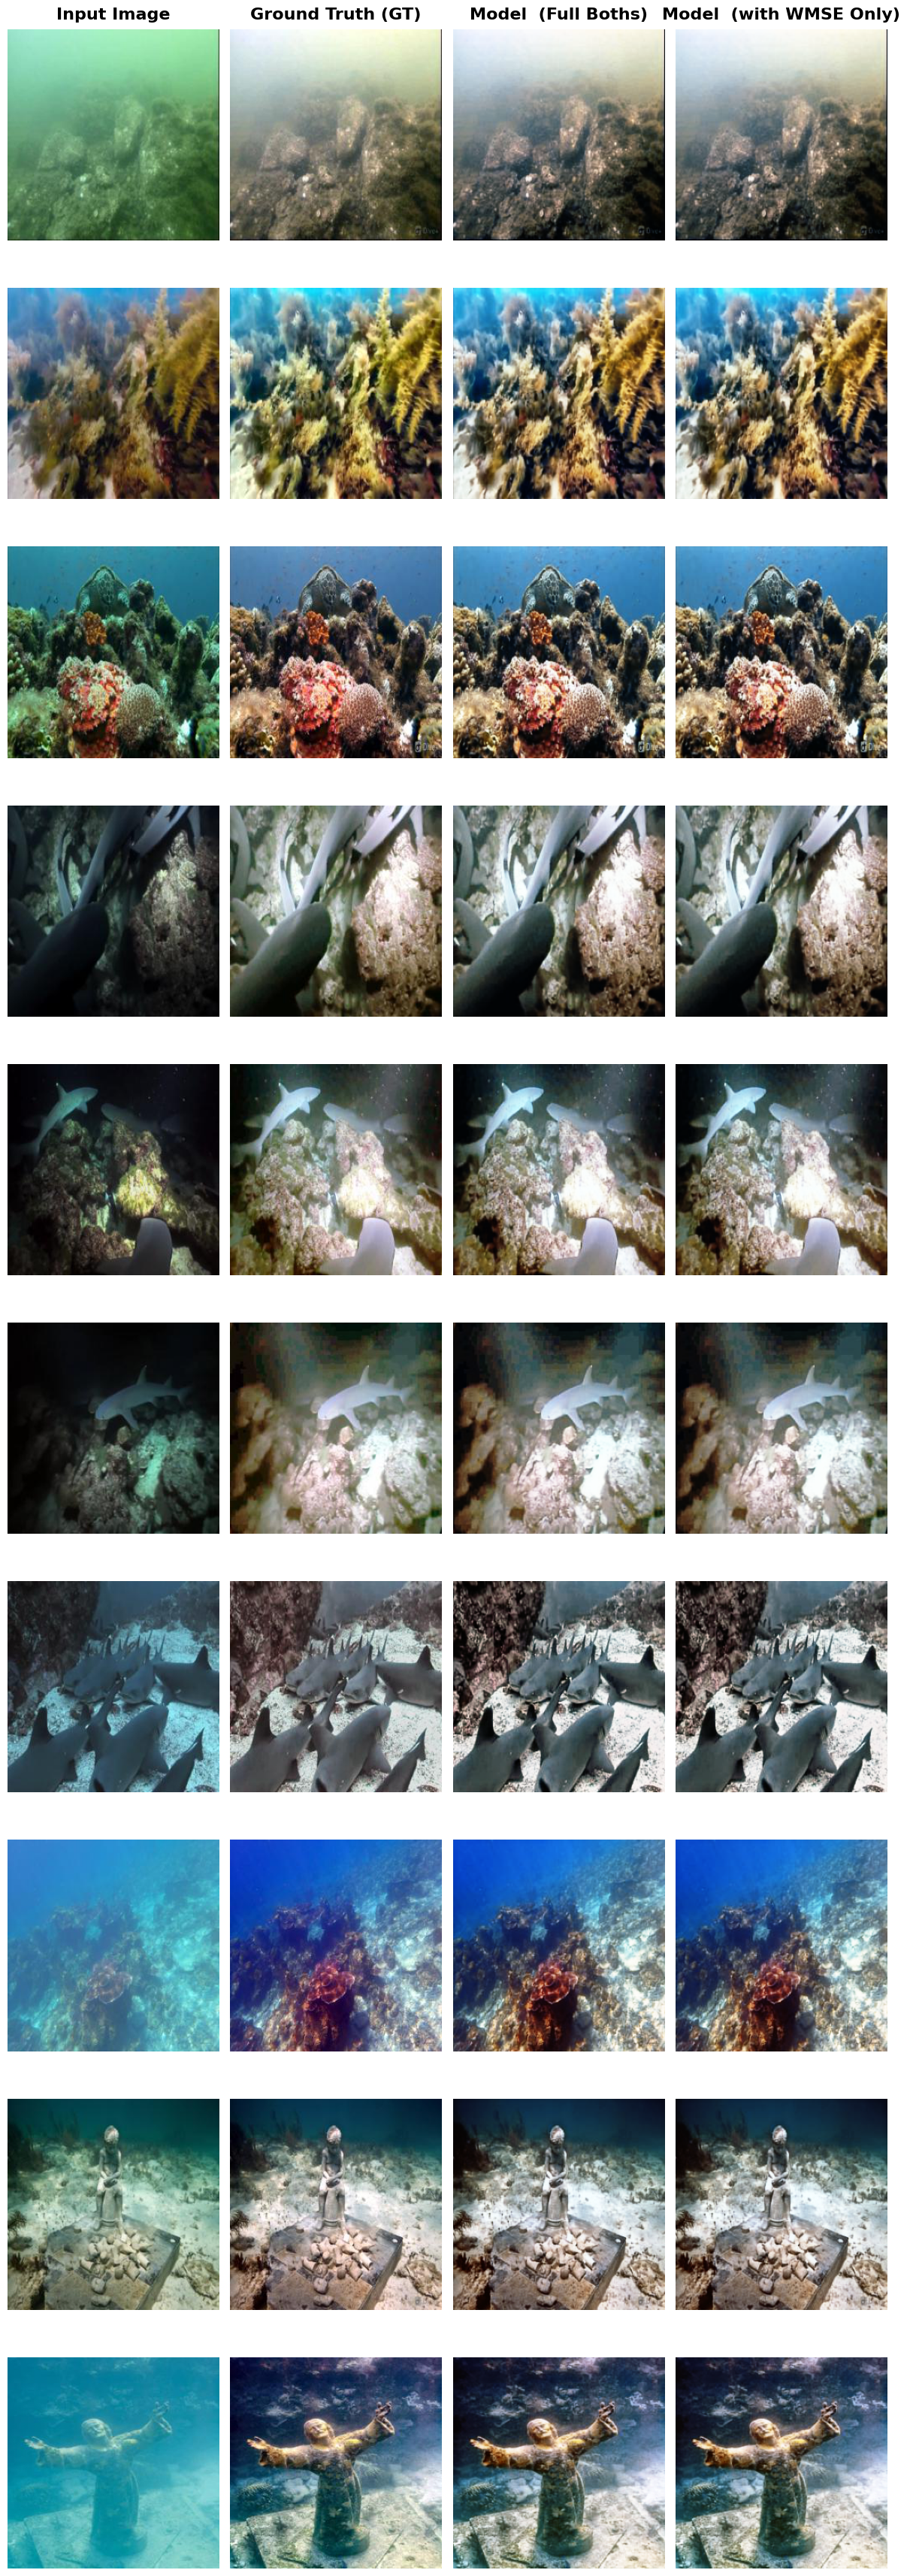

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Define Directories ---
input_dir="/content/drive/MyDrive/boths_test_inputs/"
gt_dir = "/content/drive/MyDrive/boths_test_gt/"
m1_dir = "/content/drive/MyDrive/boths_test_outputs/"
m2_dir = "/content/drive/MyDrive/boths_test_outputs_onlywmse/"

all_files = sorted([f for f in os.listdir(gt_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

#  first 10 images
selected_files = all_files[:10]



fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(12, 35))


axes[0,0].set_title("Input Image", fontsize=16, fontweight='bold', pad=10)
axes[0, 1].set_title("Ground Truth (GT)", fontsize=16, fontweight='bold', pad=10)
axes[0, 2].set_title("Model  (Full Boths)", fontsize=16, fontweight='bold', pad=10)
axes[0, 3].set_title("Model  (with WMSE Only)", fontsize=16, fontweight='bold', pad=10)

-
for i, filename in enumerate(selected_files):

    input_path = os.path.join(input_dir, filename)
    gt_path = os.path.join(gt_dir, filename)
    m1_path = os.path.join(m1_dir, filename)
    m2_path = os.path.join(m2_dir, filename)

    # Load images using PIL
    img_input=Image.open(input_path)
    img_gt = Image.open(gt_path)
    img_m1 = Image.open(m1_path)
    img_m2 = Image.open(m2_path)

    axes[i, 0].imshow(img_input)
    axes[i, 0].axis('off')

    # Plot GT
    axes[i, 1].imshow(img_gt)
    axes[i, 1].axis('off')

    # Plot Model 1
    axes[i, 2].imshow(img_m1)
    axes[i, 2].axis('off')

    # Plot Model 2
    axes[i, 3].imshow(img_m2)
    axes[i, 3].axis('off')

plt.tight_layout()


plt.show()



In [ ]:
fig.savefig("/content/drive/MyDrive/boths_comparison_grid.png", bbox_inches='tight', dpi=150)